## El Contexto de Negocio

Imagina que trabajas en el departamento de Admisión de Riesgos de un banco. Cada día, miles de clientes solicitan una nueva tarjeta de crédito a través de la app. El problema es crítico: cada vez que el banco le da una tarjeta a un cliente que luego no paga (moroso), se pierden miles de euros de golpe. Pero si el banco se asusta y rechaza a los buenos clientes, le está regalando el negocio y los intereses a la competencia.

La dirección te ha entregado un histórico de clientes reales. Su objetivo es claro: necesitan un modelo de *Credit Scoring* automático que sea capaz de predecir si un solicitante es de Alto Riesgo o Bajo Riesgo en tiempo real, antes de concederle el dinero.

## El Desafío de la industria

Este dataset es el pan de cada día en el sector financiero. Los datos no son números puros, son comportamientos humanos llenos de trampas. Tu trabajo no empieza importando Scikit-Learn; empieza entendiendo la psicología del dato:

1. **El Silencio es Información:** ¿Un valor nulo en "Tipo de Ocupación" es un fallo informático o es que el cliente está desempleado y no quiso rellenar la casilla? En banca, ocultar información es una alerta de riesgo brutal.
2. **La Maldición del Desbalanceo:** El 90% de los clientes pagan religiosamente. Si creas un algoritmo "tonto" que apruebe a todo el mundo, tendrá un 90% de *Accuracy* y parecerá perfecto. Pero en la vida real, ese modelo hundiría al banco por no detectar al 10% de morosos. 
3. **Lógica Económica vs. Matemáticas:** No puedes agrupar niveles educativos o profesiones solo porque haya pocos registros. Tendrás que aplicar *Domain Knowledge* (Conocimiento de Negocio) para clasificar a un cliente en "White Collar" o "Trabajo Temporal" basándote en su estabilidad financiera.
4. **Explicabilidad (El peso del regulador):** El Banco de España no acepta excusas. Si rechazas un crédito, tienes que poder explicar por qué. Tendrás que evaluar si te compensa usar un modelo transparente como la Regresión Logística o una "caja negra" hiper-predictiva como el Random Forest.

## El camino

Olvida el *Accuracy* académico. Tu objetivo aquí es cazar morosos.

**Hito 1:** Limpiar y transformar las variables demográficas y financieras, topando los valores extremos (outliers) y convirtiendo el texto en números sin destruir la jerarquía de los datos.

**Hito 2:** Entrenar modelos de clasificación base (Baselines) y optimizar al ganador mediante Grid Search, forzándolo a centrarse en la clase minoritaria.

**Hito 3:** Traducir las métricas matemáticas (Recall, ROC-AUC, Matriz de Confusión) a euros. Demostrarle al director de Riesgos que tu modelo es capaz de minimizar los Falsos Negativos (morosos camuflados) para salvar la cuenta de resultados del banco.

## El Objetivo: La Búsqueda del "Mejor" Modelo

Tu misión final no es entregar un archivo .ipynb con una regresión logística y darte por satisfecho. Tu objetivo es construir un Banco de Pruebas (Benchmark) donde sometas a competición a todos los "contendientes" que hemos visto en el curso:

- **Regresión Logística:** Tu línea base (Baseline). Es matemática pura, transparente y a los reguladores financieros les encanta. Pero, ¿es suficiente para capturar los patrones de impago más ocultos?

- **Árbol de Decisión:** El favorito del departamento de Negocio. Permite dibujar el perfil exacto de un moroso con reglas de "Si/No", pero ¿será capaz de generalizar sin memorizar los datos de entrenamiento?

- **Random Forest:** El "monstruo" predictivo. ¿Maximizará nuestra capacidad de cazar morosos manejando el desbalanceo, o se convertirá en una "caja negra" imposible de justificar ante el Banco de España?

Para decidir cuál es el ganador, está prohibido fijarse en el *Accuracy*. Deberás realizar un testeo cruzado basado en tres pilares de riesgo:

1. **Precisión Métrica (Orientada al Desbalanceo)**: Deberás presentar una tabla comparativa final con los resultados de cada modelo sobre el set de Test (datos que el modelo nunca ha visto):
    - **Recall (Exhaustividad)**: De todos los morosos reales que había camuflados, ¿qué porcentaje logró bloquear el modelo?
    - **ROC-AUC**: ¿Qué tan fiable es la capacidad del algoritmo para ordenar a los clientes del más seguro al más tóxico?



2. **Análisis de la Matriz de Confusión**: Un modelo puede tener métricas decentes pero arruinar al banco en la práctica. ¿Cuántos **Falsos Negativos** (morosos a los que les dimos la tarjeta y el dinero) se nos están colando? Por otro lado, ¿estamos matando el crecimiento del banco con demasiados **Falsos Positivos** (rechazando a clientes excelentes por tener un algoritmo demasiado miedoso)?

3. **Explicabilidad vs. Performance**: En el sector financiero, a veces un modelo que detecta un 2% menos de morosos es el ganador absoluto porque nos permite explicarle a Auditoría *por qué* se denegó cada crédito. Deberás justificar tu elección final basándote en este delicado equilibrio entre el poder predictivo y el cumplimiento legal.

## Instrucciones para la Entrega Final
Tu notebook debe concluir con una Sección de Juicio Crítico de Negocio:

- **Tabla de Benchmark**: Comparativa visual directa de las métricas (priorizando Recall y F1-Score) de todos los modelos testeados, incluyendo tu versión optimizada con Grid Search.

- **Justificación de Selección**: Un texto breve donde te mojes como analista: "Elijo el modelo [X] porque, aunque su Recall es ligeramente inferior al de [Y], es una caja blanca que nos permite justificar los rechazos y mantiene una tasa de Falsos Positivos mucho más rentable para el negocio".

- **Simulación en Producción**: Ejecuta tu modelo ganador pasándole 5 clientes de test seleccionados a mano para demostrar cómo el algoritmo dictamina un 0 (Crédito Aprobado) o un 1 (Crédito Denegado) en tiempo real.

## Mucha suerte!

Hasta aquí llegan todas las notas que te daré para ayudarte. 

Debajo tienes el notebook con la forma en la que resolvería yo este problema. Intenta resolverlo de forma autónoma y solo revisa como lo haría yo una vez hayas terminado tus modelos. Puedes hacer una segunda iteración mezclando lo que he hecho yo y las ideas que has tenido tú. 

Como nota, el mejor modelo que he obtenido tiene las siguientes métricas, espero que puedas superarlas!

- Accuracy: 94% con el mejor modelo maximizar accuracy. 

- Recall: 67% con el mejor modelo para esta métrica. 

## Importamos librerias que utilizaremos

In [316]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

# Carga y Cruce de Datos (Data Merging)
El primer paso de un Data Scientist real es unir la información. Ambos datasets comparten una clave única: `Ind_ID` (el identificador del cliente). Haremos un *Inner Join* para quedarnos solo con los clientes de los que tenemos tanto datos como etiqueta de riesgo.

In [ ]:
# Cargar los datasets
df_features = pd.read_csv('../Data/Credit_card.csv')
df_labels = pd.read_csv('../Data/Credit_card_label.csv')

# Cruzar los datos usando el ID del cliente
df = pd.merge(df_features, df_labels, on='Ind_ID', how='inner')

# Echamos un vistazo a las primeras filas y la dimensión
print(f"Dimensiones del dataset cruzado: {df.shape}")
display(df.head())

Dimensiones del dataset cruzado: (1548, 19)


,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


Antes de continuar vamos a ganar una primera intuición sobre mi variable respuesta. Vemos que la mayoría son buenos pagadores, y que tengo una tasa de impago del 11%.

In [318]:
df['label'].value_counts(normalize=True)

label
0    0.886951
1    0.113049
Name: proportion, dtype: float64

Echemos tambien un vistazo a mi dataset:

In [319]:
df.describe()

,Ind_ID,CHILDREN,Annual_income,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Family_Members,label
count,1.548000e+03,1548.000000,1.525000e+03,1526.000000,1548.000000,1548.0,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,5.078920e+06,0.412791,1.913993e+05,-16040.342071,59364.689922,1.0,0.208010,0.309432,0.092377,2.161499,0.113049
std,4.171759e+04,0.776691,1.132530e+05,4229.503202,137808.062701,0.0,0.406015,0.462409,0.289651,0.947772,0.316755
min,5.008827e+06,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.045070e+06,0.000000,1.215000e+05,-19553.000000,-3174.500000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,5.078842e+06,0.000000,1.665000e+05,-15661.500000,-1565.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,5.115673e+06,1.000000,2.250000e+05,-12417.000000,-431.750000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,5.150412e+06,14.000000,1.575000e+06,-7705.000000,365243.000000,1.0,1.000000,1.000000,1.000000,15.000000,1.000000


De primeras vemos que la variable ``Mobile_phone`` es 1 para todas las observaciones, así que la elimino antes de continuar:

In [320]:
df.drop('Mobile_phone', axis = 1, inplace=True)

# Limpieza e Ingeniería de Datos

Vamos a realizar un proceso de Data Wrangling para transformar las especificaciones técnicas (que vienen en formato texto) en variables numéricas que nuestros modelos puedan entender.

Empezamos eliminando la variable ``Ind_ID`` que ahora ya no necesitamos.

In [321]:
df.drop('Ind_ID', axis = 1, inplace=True)

Vamos a comprobar los formatos de mis variables. Parece que todo está en el formato correcto.

In [322]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   GENDER           1541 non-null   object 
 1   Car_Owner        1548 non-null   object 
 2   Propert_Owner    1548 non-null   object 
 3   CHILDREN         1548 non-null   int64  
 4   Annual_income    1525 non-null   float64
 5   Type_Income      1548 non-null   object 
 6   EDUCATION        1548 non-null   object 
 7   Marital_status   1548 non-null   object 
 8   Housing_type     1548 non-null   object 
 9   Birthday_count   1526 non-null   float64
 10  Employed_days    1548 non-null   int64  
 11  Work_Phone       1548 non-null   int64  
 12  Phone            1548 non-null   int64  
 13  EMAIL_ID         1548 non-null   int64  
 14  Type_Occupation  1060 non-null   object 
 15  Family_Members   1548 non-null   int64  
 16  label            1548 non-null   int64  
dtypes: float64(2),

Vamos a comprobar ahora los nulos en mis variables. Parece que tenemos unos pocos nulos o ninguno (lo cual es buena noticia) excepto para la variable ``Type_Occupation``. 

In [323]:
df.isnull().sum()

GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income       23
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
label                0
dtype: int64

In [324]:
df['Type_Occupation'].value_counts()

Type_Occupation
Laborers                 268
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Secretaries                9
Low-skill Laborers         9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: count, dtype: int64

Vemos que algunas observaciones sin el ``Type_Occupation`` informado la variable ``Employed_days`` es positivo. En la documentación podemos ver que cuando ``Employed_days > 0``, significa que está desempleado, así que voy a asumir que estos casos se corresponde basicamente a desempleados. Esto tiene sentido si tenemos en cuenta que ninguna categoría para esta variable coincide con desempleados.

In [325]:
df[(df['Type_Occupation'].isnull()) & (df['Employed_days'] > 0)]

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,0,0,0,NaN,2,1
7,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22134.0,365243,0,0,0,NaN,2,1
26,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21832.0,365243,0,1,0,NaN,2,1
27,F,N,Y,0,NaN,Pensioner,Secondary / secondary special,Married,House / apartment,-21832.0,365243,0,1,0,NaN,2,1
31,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21876.0,365243,0,1,1,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1509,F,Y,Y,0,157500.0,Pensioner,Secondary / secondary special,Widow,House / apartment,-20432.0,365243,0,0,0,NaN,1,0
1511,F,N,Y,0,216000.0,Pensioner,Higher education,Single / not married,House / apartment,-20388.0,365243,0,0,0,NaN,1,0
1514,F,N,N,0,69750.0,Pensioner,Secondary / secondary special,Widow,Municipal apartment,-21986.0,365243,0,1,0,NaN,1,0
1525,F,Y,Y,0,175500.0,Pensioner,Higher education,Married,House / apartment,-22077.0,365243,0,1,0,NaN,2,0


In [326]:
df.loc[df[(df['Type_Occupation'].isnull()) & (df['Employed_days'] > 0)].index, 'Type_Occupation'] = "Unemployed"

In [327]:
# Check de que la hemos construido bien
df['Type_Occupation'].value_counts()

Type_Occupation
Laborers                 268
Unemployed               261
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Low-skill Laborers         9
Secretaries                9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: count, dtype: int64

Como en esta variable tenemos muchas categorías y terminaremos agrupándola, dejaremos la imputación de los nulos para cuando hagamos la ingeniería de variables. 

Vamos a estudiar el resto de variables a ver como es más razonable imputar esos nulos.

Para la variable ``GENDER``, al solo tener 7 valores nulos, los vamos a imputar con el género más frecuente en nuestro dataset (el más probable o el que cabría esperar si no tenemos más información):

In [328]:
gender = df['GENDER'].value_counts()
print("Genero mas repetido:", gender.index[gender.argmax()])
df['GENDER'][df['GENDER'].isnull()] = gender.index[gender.argmax()] # Indice (es decir, genero) mas repetido en mi dataset

Genero mas repetido: F


Para el ``Annual_income`` veamos que pasa con las observaciones con ingresos a cero:

In [329]:
df[(df['Annual_income'].isnull()) | (df['Annual_income'] == 0)]

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
3,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1
12,F,Y,Y,0,NaN,Working,Secondary / secondary special,Married,House / apartment,-18950.0,-1002,1,1,0,Cooking staff,2,1
27,F,N,Y,0,NaN,Pensioner,Secondary / secondary special,Married,House / apartment,-21832.0,365243,0,1,0,Unemployed,2,1
65,F,N,Y,0,NaN,Pensioner,Higher education,Separated,House / apartment,-24611.0,365243,0,0,0,Unemployed,1,1
76,M,N,Y,1,NaN,Working,Secondary / secondary special,Single / not married,House / apartment,-12947.0,-137,0,0,0,Laborers,2,1
107,M,Y,N,0,NaN,Commercial associate,Higher education,Single / not married,Municipal apartment,-11528.0,-606,0,1,1,High skill tech staff,1,1
125,F,N,Y,0,NaN,Pensioner,Secondary / secondary special,Married,House / apartment,-22655.0,365243,0,0,0,Unemployed,2,1
152,M,Y,Y,2,NaN,Commercial associate,Higher education,Married,House / apartment,-17841.0,-4305,1,1,0,Managers,4,1
185,F,Y,Y,1,NaN,Working,Secondary / secondary special,Married,House / apartment,-14222.0,-141,1,1,0,Cooking staff,3,0
215,F,N,Y,0,NaN,Commercial associate,Secondary / secondary special,Married,House / apartment,-19310.0,-1477,0,0,0,Cleaning staff,2,0


Para ``Annual_income`` vemos que tenemos 23 nulos y que ninguna observación es cero. Aquí podríamos imputarlos como 0 para ser conservadores, pero prefiero imputar con el primer cuartil (Q1) ya que al no haber ninguna observación con 0 ingresos asumo que no será posible operacionalmente en este banco y que por tanto no tendría sentido en la práctica:

In [330]:
Q3 = df['Annual_income'].quantile(.25)
df.loc[df['Annual_income'].isnull(), 'Annual_income'] = Q3

Me queda imputar los nulos de la variable ``Birthday_count``. Esta variable indica (con signo negativo) los días que han pasado desde el nacimiento del cliente. Como no tengo más información, imputaré estos nulos con la mediana:

In [331]:
df.loc[(df['Birthday_count'].isnull()), 'Birthday_count'] = df['Birthday_count'].median()

Comprobamos que solo me quedan nulos en la variable ``Type_Occupation``, que trataré en la sección de Ingeniería de Variables.

In [332]:
df.isnull().sum()

GENDER               0
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income        0
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count       0
Employed_days        0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    227
Family_Members       0
label                0
dtype: int64

## Análisis Exploratorio

In [333]:
# Seleccionar columnas numéricas del dataframe 
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numericas: ", num_cols)
cat_cols = df.select_dtypes(include=[object]).columns.tolist()
print("Categoricas: ", cat_cols)

Numericas:  ['CHILDREN', 'Annual_income', 'Birthday_count', 'Employed_days', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Family_Members', 'label']
Categoricas:  ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']


Vemos que las variables binarias las está considerando como numéricas y no como categóricas, que es lo más razonable. Por ejemplo fíjate que ``Phone`` es 1 o 0, es decir True o False, tiene o no tiene. Por tanto, hay que transformar las variables binarias a categóricas. Por variar, vamos a hacerlo con la función ``replace``.

In [334]:
# Convertir 1 en 'Si' y 0 en 'No' en las variables binarias
df[['Work_Phone', 'Phone', 'EMAIL_ID']] = df[['Work_Phone', 'Phone', 'EMAIL_ID']].replace({1: 'Si', 0: 'No'})

# Check
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,No,No,No,Unemployed,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,Si,Si,No,NaN,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-15661.5,-586,Si,Si,No,NaN,2,1
3,F,Y,N,0,121500.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,Si,Si,No,NaN,2,1
4,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,Si,Si,No,NaN,2,1


In [335]:
# Seleccionar columnas numéricas del dataframe de nuevo
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numericas: ", num_cols)
cat_cols = df.select_dtypes(include=[object]).columns.tolist()
print("Categoricas: ", cat_cols)

Numericas:  ['CHILDREN', 'Annual_income', 'Birthday_count', 'Employed_days', 'Family_Members', 'label']
Categoricas:  ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation']


Vamos a comenzar estudiando las variables numéricas por medio de los boxplots. Primero hacemos la representación nuivariante para detectar outliers y después la haremos divididos por la varible respuesta para empezar a entender la relación del target con nuestras covariables.

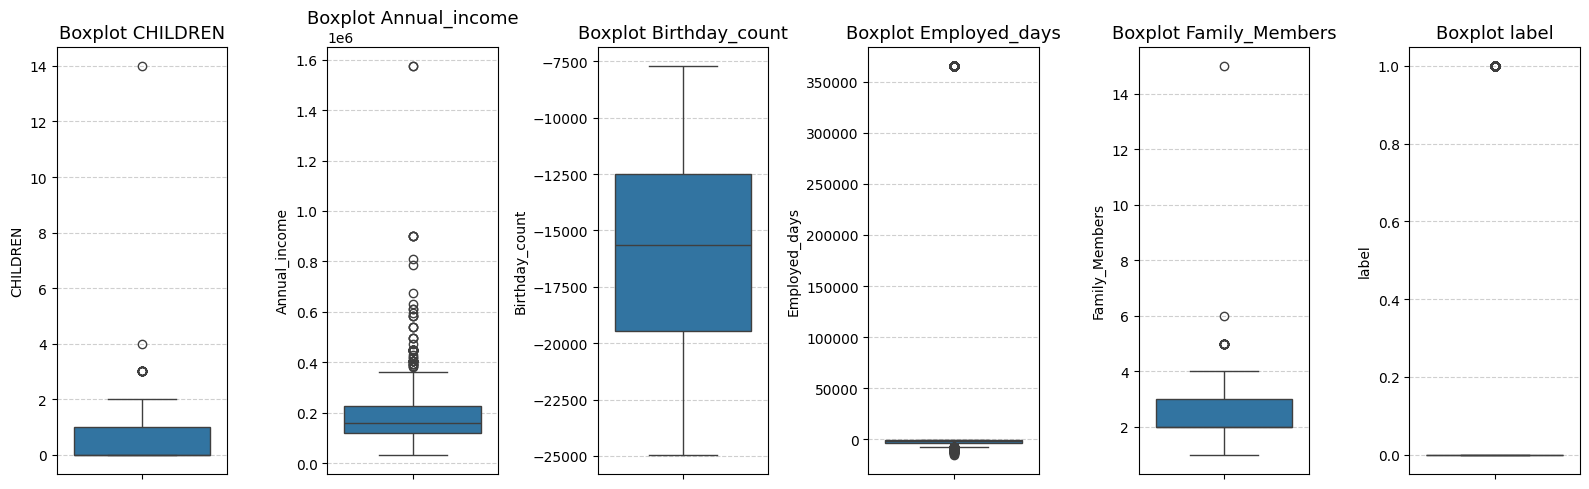

In [337]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=6, nrows=1, figsize=(16, 5))
axes = axes.flatten()

# 3. Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        orient='v',
        legend=False      # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Vemos varios outliers muy extremos que debemos corregir. Los primeros son respecto al número de familiares, que vemos que hay observaciones con datos muy extremos. Para que no afecten a nuestros modelos, voy a imputar estos outliers con el valor de 6, el valor más extremo dentro de un rango razonable según se puede ver en los boxplots, y también lo que cabría esperar a priori. 

Para etso es muy útil la función ``.clip()``, que sirve para "recortar" o poner límites por arriba (upper) o por abajo (lower) a una columna.

In [338]:
# Todo lo que sea mayor a 6, se convierte en 6. Lo que esté por debajo, se queda igual.
df['CHILDREN'] = df['CHILDREN'].clip(upper=6)
df['Family_Members'] = df['Family_Members'].clip(upper=6 + 2) # Asumiendo 6 hijos y 2 padres como max para ser coherente con la variable CHILDREN

Por darte distintas opciones, para el income imputaremos los outliers considerando el cuantil 95:

In [339]:
# Calculamos el cuantil 99 (el valor que deja por debajo al 99% de los datos)
limite_superior = df['Annual_income'].quantile(0.99)

# Imputamos: todo lo que sea mayor a ese límite, se convierte en el límite
df.loc[df['Annual_income'] > limite_superior, 'Annual_income'] = limite_superior

Para la variable ``Employed_days`` es un poco mas complicado, porque vemos que hay muchas observaciones con el valor máximo. En la documentación indica que observaciones con ``Employed_days > 0`` se corresponden con desempleados, así que simplemente vamos a transformar todos los positivos a 0, de forma que 0 signifique sin empleo y un número negativo los días que lleva trabajando. Esto lo hacemos porque asumo que no influye mucho los días que lleves sin empleo más que el hecho de estar desempleado o no. En línea con esto, después construiremos una variable que simplemente indique si el cliente tiene empleo a partir de esta variable. 

In [340]:
(df['Employed_days'] == df['Employed_days'].max()).value_counts()

Employed_days
False    1287
True      261
Name: count, dtype: int64

In [341]:
df['Employed_days'] = df['Employed_days'].clip(upper=0)
df['Employed_days'].describe()

count     1548.000000
mean     -2216.978682
std       2403.284736
min     -14887.000000
25%      -3174.500000
50%      -1565.000000
75%       -431.750000
max          0.000000
Name: Employed_days, dtype: float64

Comprobamos que ahora no tenemos outliers tan extremos:

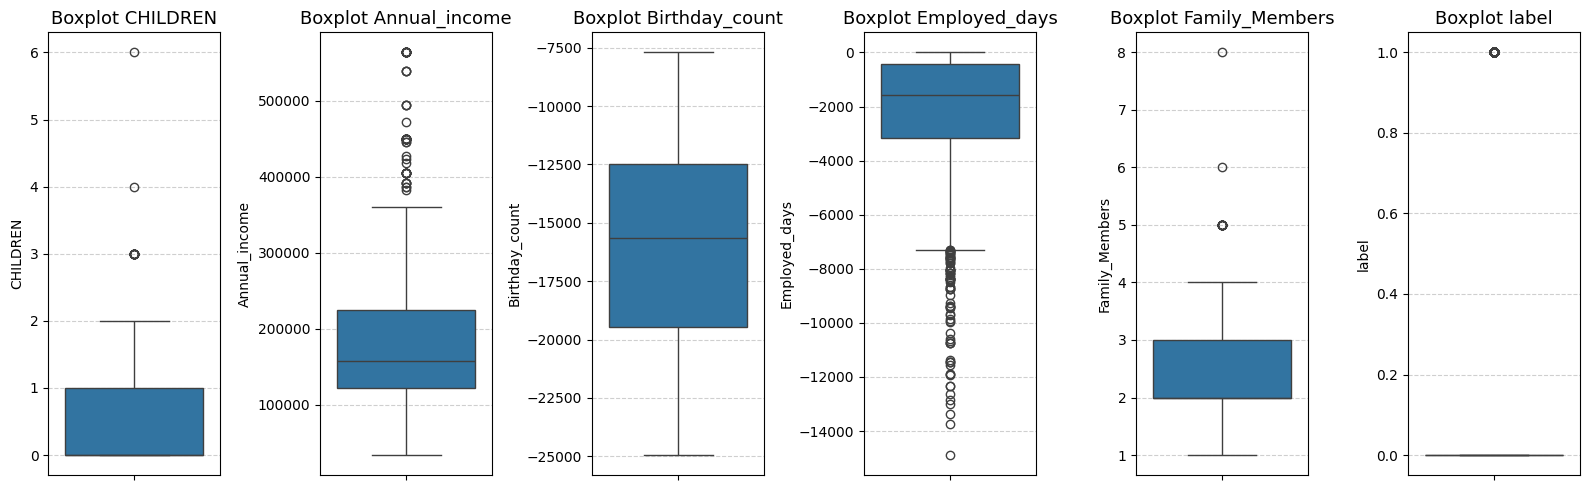

In [343]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=6, nrows=1, figsize=(16, 5))
axes = axes.flatten()

# 3. Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        orient='v',
        legend=False      # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Sigo teniendo algún atípico pero todo parece razonable, vamos a continuar con el análisis exploratorio.

Comenzamos viendo la matriz de correlaciones.

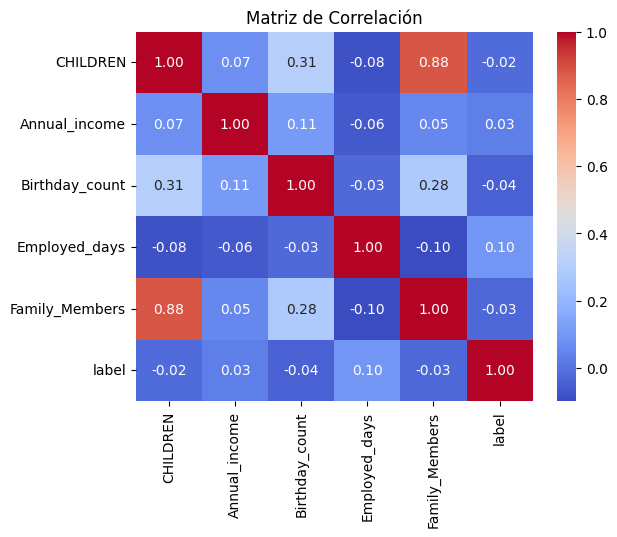

In [344]:
# MATRIZ DE CORRELACIÓN (Heatmap)
# Queremos ver qué variables tienen una relación lineal fuerte con 'Price'

# Seleccionamos solo las numéricas para la correlación
correlation_matrix = df[num_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

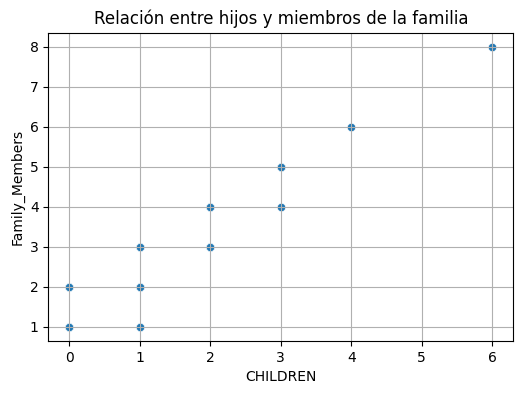

In [345]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='CHILDREN', y='Family_Members')
plt.title("Relación entre hijos y miembros de la familia")
plt.grid(True)
plt.show()

Vemos que las variables ``CHILDREN`` y ``Family_Members`` están altamente correladas (como cabría esperar). Elimino la variable ``CHILDREN`` ya que asumo que está "contenida" dentro de la otra. Para el resto no tenemos problemas de colinealidad. 

In [346]:
df.drop('CHILDREN', axis = 1, inplace=True)

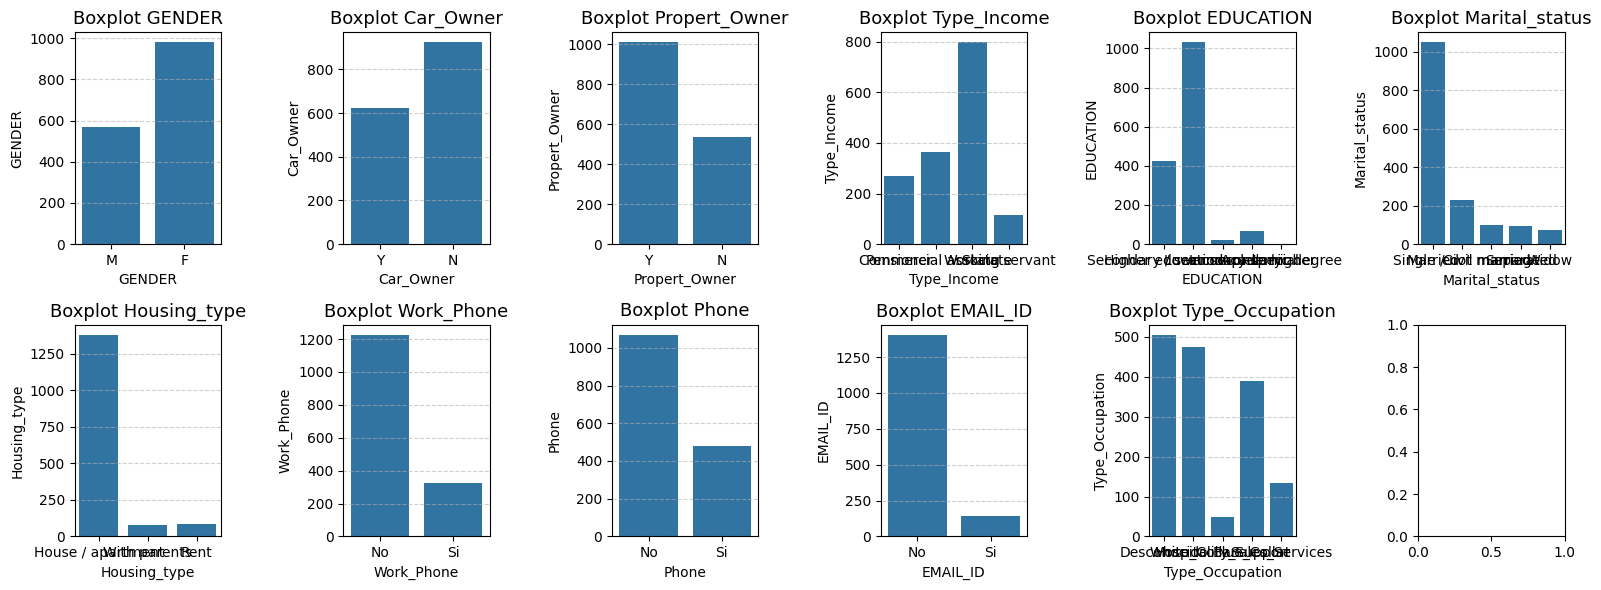

In [362]:
# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
axes = axes.flatten()

# 3. Iteración para pintar cada boxplot
for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df, 
        x=col, 
        ax=axes[i], 
        legend=False      # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Vemos muchas variables con demasiadas categorías, así que vamos a transformarlas y agruparlas para que tengan más sentido.

In [356]:
df['Marital_status'].value_counts()

Marital_status
Married                 1049
Single / not married     227
Civil marriage           101
Separated                 96
Widow                     75
Name: count, dtype: int64

No veo una forma razonable de agrupar el estado civil, así que no la tocamos al no tener muchas categorías. Fíjate que aquí es donde entra entender el problema y el negocio. A veces es preferible no agrupar variables si con esto obtenemos categorías que no tengan sentido en el negocio. Imagina agrupar casados con divorciados, conceptualmente no tendría sentido incluso teniendo sentido con los datos!

In [350]:
df.groupby('Housing_type')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
Housing_type,,
House / apartment,0.105797,1380
With parents,0.062500,80
Municipal apartment,0.301887,53
Rented apartment,0.190476,21
Office apartment,0.222222,9
Co-op apartment,0.400000,5


Vemos que las categorías con menos observaciones tienen un impago en proporción más alto. Además, todas parecen referirse a alquileres y cosas de este estilo, así que las vamos a agrupar en una sola categoría "Rent":

In [353]:
# Definimos nuestro límite de obsercaciones
threshold = 60

# Calculamos cuántos clientes hay en cada categoría
frecuencias = df['Housing_type'].value_counts()

# Filtramos y nos quedamos solo con los NOMBRES de las categorías que no llegan a X
categorias_raras = frecuencias[frecuencias < threshold].index

# Reemplazamos todas esas categorías minoritarias por la palabra 'Rent'
df['Housing_type'] = df['Housing_type'].replace(categorias_raras, 'Rent')

# Comprobamos el resultado
df.groupby('Housing_type')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
Housing_type,,
House / apartment,0.105797,1380
Rent,0.272727,88
With parents,0.062500,80


In [360]:
df.groupby('Type_Occupation', dropna=False)['label'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
Type_Occupation,,
IT staff,1.000000,2
Security staff,0.320000,25
Low-skill Laborers,0.222222,9
Waiters/barmen staff,0.200000,5
Cooking staff,0.190476,21
Unemployed,0.134100,261
Core staff,0.132184,174
Accountants,0.113636,44
High skill tech staff,0.107692,65


En líne con lo que comentaba para el estado civil, la ocupación debería agruparse también de forma que tenga cierto sentido. Esto es más casi arte que ciencia, porque si te fijas, los datos indican que la gente de IT impaga siempre, lo cual a priori no tendría sentido. De igual forma, los datos sugieren agrupar Managers (que suelen tener un salario elevado) con limpiadores (que suelen tener salarios más bajos). 

Podríamos agrupar olvidandonos de esto, pero sería dificil de explicar. Por tanto, voy a coger el siguiente diccionario (asistencia de ChatGPT) para agrupar la variable por "categorías" olvidándome de la variable respuesta. Puedes probar a agrupar por tasa de impago y comprobar si obtendrías mejores resultados, así vas cogiendo una intuición de cuando compensa "romper" un poco la lógica del negocio y cuando no. 

In [361]:
# Creamos el diccionario de mapeo con nuestra lógica de negocio
mapeo_profesiones = {
    # White Collar (Oficina / Alta cualificación)
    'IT staff': 'White_Collar',
    'Managers': 'White_Collar',
    'Core staff': 'White_Collar',
    'Accountants': 'White_Collar',
    'Medicine staff': 'White_Collar',
    'High skill tech staff': 'White_Collar',
    'HR staff': 'White_Collar',
    
    # Blue Collar (Manual / Operativo)
    'Laborers': 'Blue_Collar',
    'Drivers': 'Blue_Collar',
    'Security staff': 'Blue_Collar',
    'Low-skill Laborers': 'Blue_Collar',
    
    # Ventas y Administración
    'Sales staff': 'Sales_Services',
    'Realty agents': 'Sales_Services',
    'Secretaries': 'Sales_Services',
    
    # Hostelería y Limpieza
    'Cooking staff': 'Hospitality_Support',
    'Waiters/barmen staff': 'Hospitality_Support',
    'Cleaning staff': 'Hospitality_Support'
}

# Aplicamos el mapeo. Lo que no esté en el diccionario (los nulos), lo rellenamos con 'Desconocido'
df['Type_Occupation'] = df['Type_Occupation'].map(mapeo_profesiones).fillna('Desconocido')

# Comprobamos la nueva distribución y su Tasa de Mora
df.groupby('Type_Occupation')['label'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
Type_Occupation,,
Hospitality_Support,0.145833,48
Blue_Collar,0.121134,388
White_Collar,0.113924,474
Desconocido,0.112871,505
Sales_Services,0.075188,133


Respecto a la variable ``EDUCATION``, vamos a agrupar las dos categorías con menos observaciones para que no introduzcan ruido en nuestro modelo. Fíjate como al tener una frecuencia bajan tienen unos valores extremos en la variable respuesta, por tanto preferimos eliminar esta variabilidad extrema por culpa del número de observaciones. Las agrupamos con la categorías más similar en términos de nivel de estudios.

In [369]:
df.groupby('EDUCATION')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
EDUCATION,,
Secondary / secondary special,0.105723,1031
Higher education,0.129108,426
Incomplete higher,0.073529,68
Lower secondary,0.285714,21
Academic degree,0.000000,2


In [370]:
df['EDUCATION'] = df['EDUCATION'].replace('Academic degree', 'Higher education')
df['EDUCATION'] = df['EDUCATION'].replace(['Lower secondary', 'Secondary / secondary special'], 'Secondary')
df.groupby('EDUCATION')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
EDUCATION,,
Secondary,0.109316,1052
Higher education,0.128505,428
Incomplete higher,0.073529,68


Comprobamos como han quedado las variables categóricas, ahora de paso desagregando por impago para empezar a ver qué variables puedes ser más interesantes para predecir impagos.

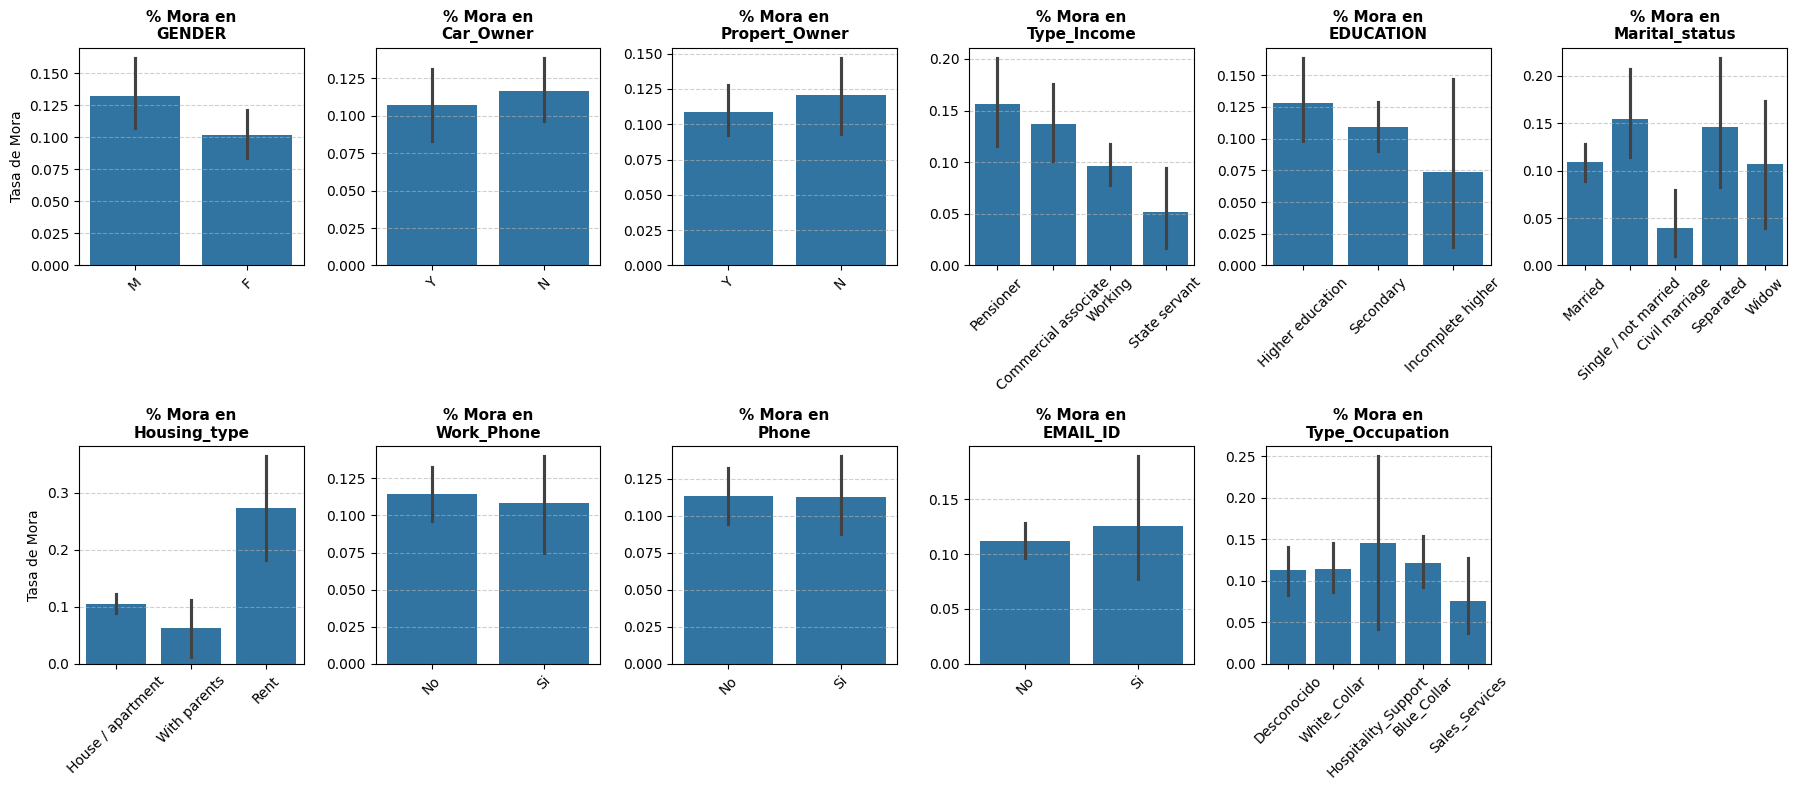

In [371]:
# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(18, 8)) # Un poco más grande para que quepan los textos
axes = axes.flatten()

# Iteración para pintar cada gráfico de barras con el % (Tasa de Mora)
for i, col in enumerate(cat_cols):
    # sns.barplot calcula la media por defecto (que en variables 0/1 es el %)
    sns.barplot(
        data=df, 
        x=col, 
        y='label',       # Al poner label en la Y, calcula la proporción de 1s
        ax=axes[i]
    )
    
    # Rotamos las etiquetas X porque en variables categóricas suelen solaparse
    axes[i].tick_params(axis='x', rotation=45) 
    
    # Títulos y etiquetas más precisos
    axes[i].set_title(f'% Mora en\n{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tasa de Mora' if i % 6 == 0 else '') # Solo mostramos el nombre del eje Y en la primera columna
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Si tienes menos de 12 variables categóricas, esto borra los subplots vacíos que sobran
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Parece que las variables están mucho más limpias y además tienen sentido en términos de impago. 

También vemos variables, como ``Propert_Owner`` por ejemplo, que no parecen tener mucha capacidad predictiva. Podríamos eliminarlas para introducir el mínimo ruido posible en nuestros modelos. También existen técnicas y métricas para detectar variables con poco poder predictivo y eliminarlas. Como esto es un curso introductorio, solo quiero que sepas que existen.

Para hacerlo más didáctico, elimino las variables relacionadas con el teléfono que vemos que tienen muy poca capacidad de separar entre impagos y buenos pagadores. Las de tipo "owner" las mantengo ya que aún no teniendo mucha capacidad predictiva a simple vista, tienen sentido. Fíjate por ejemplo que tener una casa reduce la probabilidad de imago. Esto tiene sentido porque alguien con una casa suele tener una economía más estable que alguien que vive de alquiler, por ejemplo. 

In [372]:
df.drop(['Work_Phone', 'Phone'], axis = 1, inplace=True)

Vamos a ver ahora la relación de las variables numéricas y nuestra variable de interés.

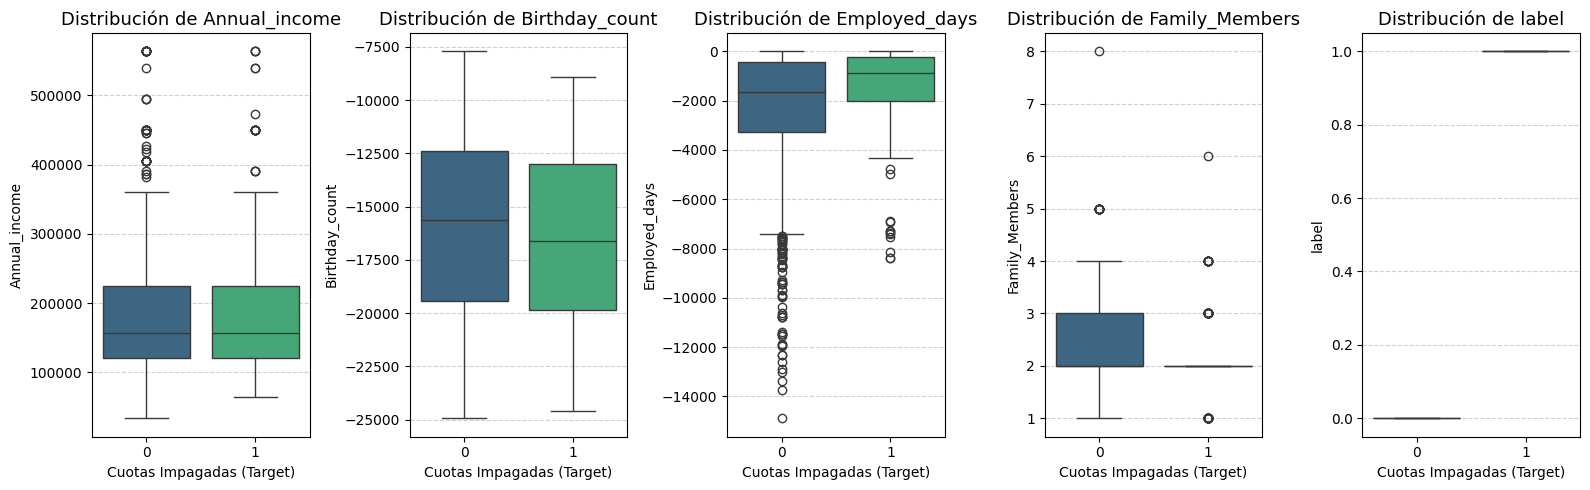

In [377]:
# Extraer de nuevo variables numericas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(16, 5))
axes = axes.flatten()

# Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        x='label', 
        y=col, 
        ax=axes[i], 
        palette='viridis',
        orient='v',
        hue='label',       # Añade color por categoría
        legend=False      # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=13)
    axes[i].set_xlabel('Cuotas Impagadas (Target)')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Sorprendentemente el income no tiene mucha diferencia entre buenos y malos pagadores, pero si los miembros de la familia. 

# Modelizacion



Comenzamos como siempre definiendo la matriz con las variables predictoras y mi variable respuesta (``label``).

In [378]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

A continuación terminamos de formatear el dataframe construyendo las variables dummy y escalando las variables numéricas.

In [380]:
# Crear dummies
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# drop_first=True elimina la primera columna para evitar la trampa de multicolinealidad
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alineamos las columnas del Train/Test
X_test = X_test.reindex(columns = X_train.columns, fill_value=0)

In [381]:
# Escalamos variables numericas
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Definicion del scaler
scaler = StandardScaler()

# Ajustamos (fit) SOLO con el train y transformamos ambos
# Esto evita que el modelo sepa de antemano el rango total de los datos de prueba
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Comprobamos que hemos hecho tanto la estandarización como la creación de dummies correctamente. 

In [383]:
X_train.head()

,Annual_income,Birthday_count,Employed_days,Family_Members,GENDER_M,Car_Owner_Y,Propert_Owner_Y,Type_Income_Pensioner,Type_Income_State servant,Type_Income_Working,...,Marital_status_Separated,Marital_status_Single / not married,Marital_status_Widow,Housing_type_Rent,Housing_type_With parents,EMAIL_ID_Si,Type_Occupation_Desconocido,Type_Occupation_Hospitality_Support,Type_Occupation_Sales_Services,Type_Occupation_White_Collar
730,-0.566005,0.307107,0.379775,-1.268853,False,False,True,False,False,True,...,True,False,False,False,False,False,True,False,False,False
100,-1.070621,0.246217,-1.887380,0.908909,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
619,-1.070621,1.396177,0.549271,0.908909,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
838,-1.254117,1.051692,-0.234084,-0.179972,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1419,-0.795376,-1.339562,0.916851,-1.268853,False,False,False,True,False,False,...,True,False,False,True,False,False,True,False,False,False


In [390]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score

# Definición de Modelos (Añadimos class_weight='balanced' como vimos antes por los morosos)
modelos = {
    "Logística": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Árbol": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    "Random Forest Base": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

# Entrenamiento y Evaluación
resultados = []

for nombre, mod in modelos.items():
    # 1. Entrenar
    mod.fit(X_train, y_train)
    
    # 2. Predecir (0 o 1) para Recall y F1
    preds = mod.predict(X_test)
    
    # 3. Predecir probabilidades (porcentaje) para el AUC
    probs = mod.predict_proba(X_test)[:, 1]
    
    # 4. Calcular métricas
    auc = roc_auc_score(y_test, probs)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    # 5. Guardar resultados
    resultados.append({
        "Modelo": nombre, 
        "ROC-AUC": auc,
        "Recall": recall,
        "F1-Score": f1
    })

# Convertimos a DataFrame, multiplicamos por 100 y ordenamos por el Recall (Caza-Morosos)
df_benchmark = pd.DataFrame(resultados).set_index("Modelo")
df_benchmark = (df_benchmark * 100).round(2)
df_benchmark.sort_values(by="Recall", ascending=False)

,ROC-AUC,Recall,F1-Score
Modelo,,,
Logística,66.11,67.44,24.17
Árbol,63.29,46.51,23.12
Random Forest Base,84.86,44.19,60.32


Vamos a extraer también las predicciones cno cada modelo para el análisis comparativo final.

In [392]:
# Creamos un diccionario vacío para guardar las predicciones de cada modelo
diccionario_predicciones = {}

for nombre, mod in modelos.items():
    mod.fit(X_train, y_train)
    
    # Guardamos las predicciones (0 y 1) asociadas al nombre del modelo
    diccionario_predicciones[nombre] = mod.predict(X_test)

# Ahora puedes extraerlas así para usarlas donde quieras:
predicciones_lr = diccionario_predicciones["Logística"]
predicciones_tree = diccionario_predicciones["Árbol"]
predicciones_rf = diccionario_predicciones["Random Forest Base"]

Vamos hacer ahora el grid search para entrenar el modelo Random Forest e intentar obtener mejores predicciones: 

In [387]:
from sklearn.model_selection import GridSearchCV

# Definimos la cuadrícula (Grid) de parámetros a explorar
# Mantenemos las opciones acotadas para que no tarde 3 horas en entrenar
param_grid = {
    'n_estimators': [50, 100, 200],       # Cuántos árboles plantamos en el bosque
    'max_depth': [5, 10, None],           # Profundidad máxima (para que no se aprendan cada cliente de memoria)
    'min_samples_leaf': [1, 5, 10]        # Mínimo de clientes en la decisión final (evita ramas inútiles)
}

# Instanciamos el modelo base
# Mantenemos class_weight='balanced' para que siga dándole peso a los morosos
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# Configuramos el buscador
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='roc_auc',    # Métrica de negocio: Queremos el modelo que separe mejor a buenos de malos
    cv=5,                 # Validación cruzada (Cross-Validation) de 5 pliegues
    verbose=2             # Nos irá imprimiendo por pantalla por dónde va
)

# Lanzamos el entrenamiento (Aviso: Esto probará 3x3x3 = 27 combinaciones x 5 pliegues (CV) = 135 entrenamientos)
grid_search.fit(X_train, y_train)

# Guardamos al mejor modelo
mejor_rf = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   0.0s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   0.0s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   0.0s
[CV] END ...max_depth=5, min_samples_leaf=1, n_estimators=50; total time=   0.0s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=200; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_e

In [388]:
print(f"Mejores hiperparámetros encontrados:\n{grid_search.best_params_}")

Mejores hiperparámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}


Ahora vamos a comprobar los resultados de nuestro modelo de Random Forest óptimo y los demás modelos que hemos entrenado con detalle.

In [395]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, f1_score

# Hacemos las predicciones con el modelo ganador del Grid Search
predicciones_mejor_rf = mejor_rf.predict(X_test)
# Para el ROC-AUC necesitamos las probabilidades (la confianza del modelo), no solo ceros y unos
probabilidades_mejor_rf = mejor_rf.predict_proba(X_test)[:, 1] 

# Recopilamos las métricas de todos los modelos en un diccionario
# (Asumimos que ya tenías guardadas las predicciones de los modelos base)
resultados = {
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'RF Base', 'RF Optimizado'],
    'Accuracy (Aciertos)': [
        accuracy_score(y_test, predicciones_lr),
        accuracy_score(y_test, predicciones_tree),
        accuracy_score(y_test, predicciones_rf),
        accuracy_score(y_test, predicciones_mejor_rf)
    ],
    'Recall (Caza-Morosos)': [
        recall_score(y_test, predicciones_lr),
        recall_score(y_test, predicciones_tree),
        recall_score(y_test, predicciones_rf),
        recall_score(y_test, predicciones_mejor_rf)
    ],
    'ROC-AUC (Poder de Ranking)': [
        roc_auc_score(y_test, predicciones_lr),
        roc_auc_score(y_test, predicciones_tree),
        roc_auc_score(y_test, predicciones_rf),
        roc_auc_score(y_test, probabilidades_mejor_rf)
    ],
    'F1-Score (Equilibrio)': [
        f1_score(y_test, predicciones_lr),
        f1_score(y_test, predicciones_tree),
        f1_score(y_test, predicciones_rf),
        f1_score(y_test, predicciones_mejor_rf)
    ]
}

# Creamos el DataFrame, lo multiplicamos por 100 para ver % y lo ordenamos por Recall
df_benchmark = pd.DataFrame(resultados)
df_benchmark.set_index('Modelo', inplace=True)
df_benchmark = (df_benchmark * 100).round(2)

# Mostramos la tabla ordenada de mejor a peor cazador de morosos
df_benchmark.sort_values(by='Recall (Caza-Morosos)', ascending=False)

,Accuracy (Aciertos),Recall (Caza-Morosos),ROC-AUC (Poder de Ranking),F1-Score (Equilibrio)
Modelo,,,,
Regresión Logística,60.86,67.44,63.82,24.17
Árbol de Decisión,71.40,46.51,60.22,23.12
RF Base,94.62,44.19,71.97,60.32
RF Optimizado,94.41,44.19,84.13,59.38


Vemos que el Random Forest es claramente mejor a los demás modelos en térmios de AUC, accuracy y F1, pero sin embargo en términos del Recall (los impagos que detectamos) el mejor modelo es la Regresión Logística. Por tanto, dependiendo de los objetivos del banco eligríamos un modelo u otro:

- Regresión logística: Si el modelo debe ser interpretable o el banco es conservador y su objetivo principal es detectar a los morosos más que tener una alta accuracy. 

- Random Forest: Si el objetivo es maximizar la accuracy independientemente del % de acierto en mororos. 

Esto puede ser un poco antiuitivo, pero en problemas desbalanceados como este (solo el 11% son morosos) ocurren muchas veces estas cosas. De ahí que sea tan importante entender todas las métricas para seleccionar el modelo más adecuado.

Espero que hayas podido llegar a un modelo tan bueno como este e incluso mejor. Podrías haber hecho una limpieza de variables distintas, construir más variables, utilizar más modelos o más hiperparámetros... Las posibilidades son infinitas ahora que dominas Python y el ML, así que espero tu mensaje diciendo que has obtenido un error más bajo al mío ;)

Y por supuesto, enhorabuena, después de llegar hasta aquí ya has aprendido todo lo que necesitas para resolver un problema de clasifiación como un Data Scientist pro.